In [1]:
import scanpy as sc
import numpy as np 
import sys
import os
import pickle as pkl
from pathlib import Path
import pandas as pd
import yaml
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, "../../../../shared_utils/")
from experiment_utils import compute_sequential_local_penalization

In [2]:
def plot_wucb_ranking_results(
    result_df,
    axes=None,
    column_to_track="losses",
    markersize=3
):
    tracked_acqs = result_df["acq_values"]
    tracked_losses = result_df[column_to_track]

    epochs = np.arange(1, len(tracked_acqs) + 1)

    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(7, 4))
    ax1, ax2 = axes

    # Plot 1: Acquisition values
    ax1.plot(
        epochs,
        tracked_acqs,
        marker='o',
        linestyle='-',
        linewidth=1,
        markersize=markersize,
        markeredgewidth=0.5,
        color="firebrick"
    )
    ax1.set_title("Acquisition Value", fontsize=10)
    ax1.set_xlabel("Selection Step", fontsize=8)
    ax1.set_ylabel("Penalized Acquisition Value", fontsize=8)
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Predicted losses
    ax2.plot(
        epochs,
        tracked_losses,
        marker='s',
        linestyle='-',
        linewidth=1,
        markersize=markersize,
        markeredgewidth=0.5,
        color="royalblue"
    )
    ax2.set_title("Predicted Loss", fontsize=10)
    ax2.set_xlabel("Selection Step", fontsize=8)
    ax2.set_ylabel("Mean Predicted Loss", fontsize=8)
    ax2.grid(True, linestyle='--', alpha=0.7)

    return axes

In [3]:
# Annotation file 
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [4]:
path_to_annotated_filter = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original/annotated")

In [5]:
cell_type_dfs = {}

# for file in os.listdir(path_to_annotated_filter):
#     cell_type = file.split("_")[2].replace(".csv", "")
#     # cell_type_dfs[cell_type] = pd.read_csv(path_to_annotated_filter / file).loc[:, protocol_cols]
#     cell_type_dfs[cell_type] = pd.read_csv(path_to_annotated_filter / file)

with open("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original/fitlered_populations.pkl", "rb") as file:
    cell_type_dfs = pkl.load(file)

In [6]:
results_acqn = {}

for cell_type in tqdm(cell_type_dfs):
    X_candidates = cell_type_dfs[cell_type].loc[:, protocol_cols].values
    mean_candidate_loss = cell_type_dfs[cell_type]["target_ct_loss_mean"].values
    std_candidate_loss = cell_type_dfs[cell_type]["uncertainty_loss"].values
    sequential_penalization_results = compute_sequential_local_penalization(X_candidates, mean_candidate_loss, std_candidate_loss, gamma=0.1)
    for key in sequential_penalization_results:
        if cell_type not in results_acqn:
            results_acqn[cell_type] = {}
        results_acqn[cell_type][key] = sequential_penalization_results[key]

100%|██████████| 10/10 [00:16<00:00,  1.63s/it]


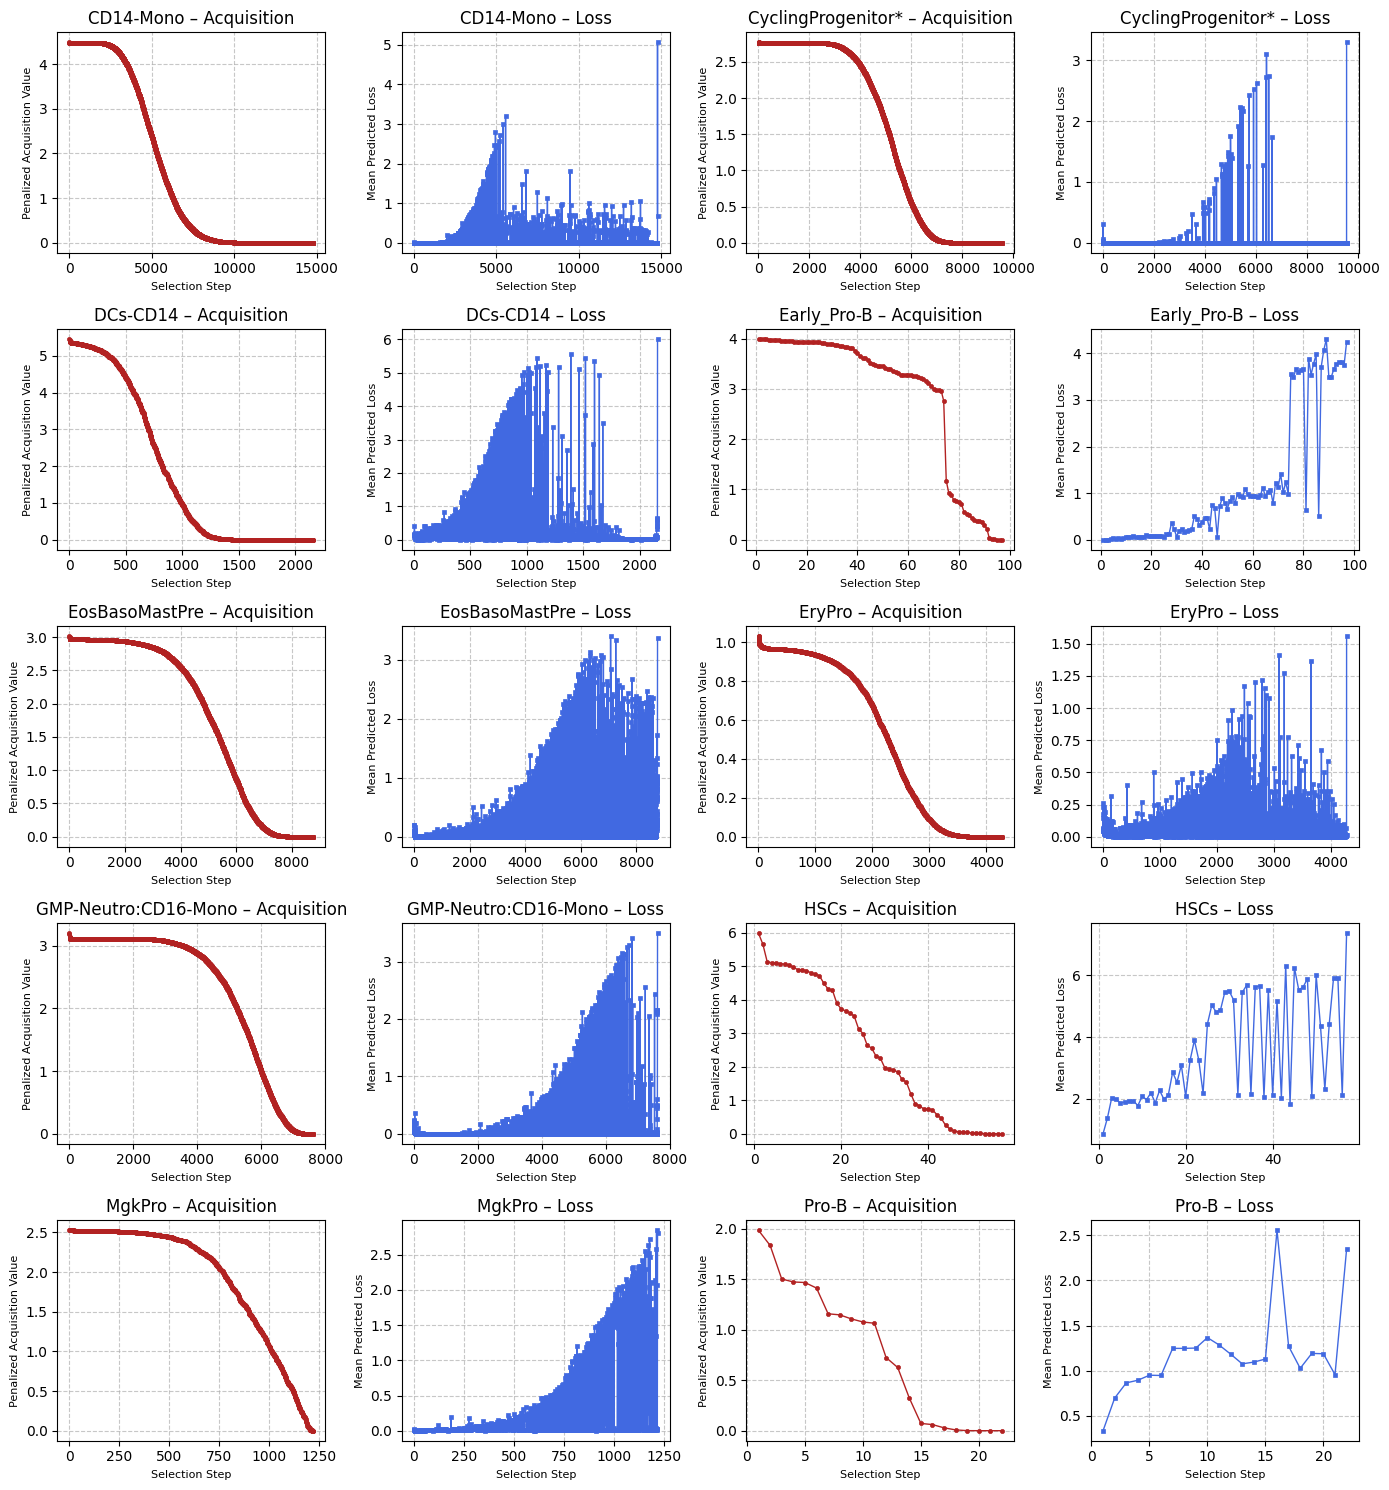

In [7]:
import math 
cell_types = list(cell_type_dfs.keys())
n = len(cell_types)

rows = math.ceil(n / 2)   # 2 cell types per row
cols = 4                  # (acq, loss) × 2

fig, axes = plt.subplots(rows, cols, figsize=(14, 3*rows))

for i, cell_type in enumerate(cell_types):
    r = i // 2
    c = (i % 2) * 2   # start column for this cell type

    plot_wucb_ranking_results(
        result_df=results_acqn[cell_type],
        axes=(axes[r, c], axes[r, c+1]),
    )

    axes[r, c].set_title(f"{cell_type} – Acquisition")
    axes[r, c+1].set_title(f"{cell_type} – Loss")

# Hide unused axes if odd number of cell types
total_axes = rows * cols
used_axes = n * 2
axes_flat = axes.flatten()

for j in range(used_axes, total_axes):
    axes_flat[j].axis("off")

plt.tight_layout()
plt.show()

In [8]:
results_acqn

{'CD14-Mono': {'indices': array([14078, 12766, 12785, ..., 10637, 14251, 14747], shape=(14783,)),
  'losses': array([2.4748785e-02, 4.8281136e-04, 1.0449777e-04, ..., 6.6909350e-05,
         5.0641820e+00, 6.7493740e-01], shape=(14783,)),
  'acq_values': array([4.48895174, 4.47945576, 4.47937553, ..., 0.        , 0.        ,
         0.        ], shape=(14783,))},
 'CyclingProgenitor*': {'indices': array([9490, 9504, 9489, ..., 3510, 1222, 9550], shape=(9554,)),
  'losses': array([0.0361424 , 0.3122855 , 0.03482523, ..., 0.        , 0.        ,
         3.2985656 ], shape=(9554,)),
  'acq_values': array([2.76980655e+00, 2.76925953e+00, 2.76786353e+00, ...,
         7.70252190e-56, 5.57523116e-58, 0.00000000e+00], shape=(9554,))},
 'DCs-CD14': {'indices': array([ 953, 1511, 1554, ..., 1848, 1852, 2087], shape=(2157,)),
  'losses': array([0.18078008, 0.15439562, 0.15456091, ..., 0.56118745, 0.523389  ,
         5.99204   ], shape=(2157,)),
  'acq_values': array([5.4501582 , 5.42430285, 5

In [9]:
results_acqn

{'CD14-Mono': {'indices': array([14078, 12766, 12785, ..., 10637, 14251, 14747], shape=(14783,)),
  'losses': array([2.4748785e-02, 4.8281136e-04, 1.0449777e-04, ..., 6.6909350e-05,
         5.0641820e+00, 6.7493740e-01], shape=(14783,)),
  'acq_values': array([4.48895174, 4.47945576, 4.47937553, ..., 0.        , 0.        ,
         0.        ], shape=(14783,))},
 'CyclingProgenitor*': {'indices': array([9490, 9504, 9489, ..., 3510, 1222, 9550], shape=(9554,)),
  'losses': array([0.0361424 , 0.3122855 , 0.03482523, ..., 0.        , 0.        ,
         3.2985656 ], shape=(9554,)),
  'acq_values': array([2.76980655e+00, 2.76925953e+00, 2.76786353e+00, ...,
         7.70252190e-56, 5.57523116e-58, 0.00000000e+00], shape=(9554,))},
 'DCs-CD14': {'indices': array([ 953, 1511, 1554, ..., 1848, 1852, 2087], shape=(2157,)),
  'losses': array([0.18078008, 0.15439562, 0.15456091, ..., 0.56118745, 0.523389  ,
         5.99204   ], shape=(2157,)),
  'acq_values': array([5.4501582 , 5.42430285, 5